In [1]:
%%html
<style>
table {float:left}
</style>

# <font color="darkgray">Quantum Reservoir Computing</font><br><small><small><strong>With Classical Echo State Network</strong> and<br><strong>Quantum Feature Map</strong></small></small>

<table>
    <tr><td><strong>Aim:</strong></td>
        <td>To create and use a quantum reservoir computing model in <strong>PennyLane</strong>.<br>
            Compare this quantum reservoir with the equivalent classical reservoir.</td></tr>
    <tr><td><strong>Author:</strong></td>
        <td>Jacob L. Cybulski (<a href="https://jacobcybulski.com/" target="_blank">website</a>),
            <em>Enquanted</em></td></tr>
    <tr><td><strong>Release:</strong></td>
        <td>April 2025</td></tr>
    <tr><td><strong>Datasets:</strong></td>
        <td>We will use the the Mackey-Glass time series generator (code included)</td></tr>
    <tr><td><strong>Timeframe:</strong></td>
        <td>01/07/25-26/09/25 (possible extensions)</td></tr>
    <tr><td><strong>References:</strong></td>
        <td>Unfortunately, there is no single simple formulation of a quantum reservoir. 
            Numerous papers have been checked for some good insights, including:
            <ul>
            <li>A. H. Abbas, H. Abdel-Ghani, and I. S. Maksymov, 
                “Classical and Quantum Physical Reservoir Computing for Onboard Artificial Intelligence Systems: A Perspective,” 
                Dynamics, vol. 4, no. 3, pp. 643–670, Aug. 2024, doi: 10.3390/dynamics4030033.</li>
            <li>J. Chen, H. I. Nurdin, and N. Yamamoto, 
                “Temporal Information Processing on Noisy Quantum Computers,” 
                Phys. Rev. Appl., vol. 14, no. 2, p. 024065, Aug. 2020, doi: 10.1103/PhysRevApplied.14.024065.</li>
            <li>K. Fujii and K. Nakajima, 
                “Quantum reservoir computing: a reservoir approach toward quantum machine learning on near-term quantum devices,” 
                Nov. 10, 2020, arXiv: arXiv:2011.04890. doi: 10.48550/arXiv.2011.04890.</li>
            <li>N. Götting, F. Lohof, and C. Gies, 
                “Exploring quantumness in quantum reservoir computing,” 
                Phys. Rev. A, vol. 108, no. 5, p. 052427, Nov. 2023, doi: 10.1103/PhysRevA.108.052427.</li>
            <li>P. Mujal et al., 
                “Opportunities in Quantum Reservoir Computing and Extreme Learning Machines,” 
                Adv. Quantum Technol., vol. 4, no. 8, p. 2100027, Aug. 2021, doi: 10.1002/qute.202100027.</li>
            <li>Q. H. Tran, S. Ghosh, and K. Nakajima, 
                “Quantum-classical hybrid information processing via a single quantum system,” 
                Phys. Rev. Res., vol. 5, no. 4, p. 043127, Nov. 2023, doi: 10.1103/PhysRevResearch.5.043127.</li>
            <li>T. Yasuda et al., 
                “Quantum reservoir computing with repeated measurements on superconducting devices,” 
                Oct. 10, 2023, arXiv: arXiv:2310.06706. doi: 10.48550/arXiv.2310.06706.</li>
        </ul>
        And some others...</td>
    </tr>
    <tr><td><strong>License:</strong></td>
        <td>This project is licensed under the
            <a href="./LICENSE" target="_blank">GNU General Public License V3</a></td></tr>
</table>

### Quantum reservoir computing (QRC)
QRC is a quantum approach to the creation of Reservoir Computing, which is a concepts derived from recurrent neural networks (RNN). 
It can be applied to all types of data, however, it is especially useful for temporal data. 
Reservoir computing utilises a large sparse neural network of randomly initialised and fixed weights (_**reservoir**_),
responsible for transforming input into a higher-dimensional space.
In high-dimensional space, data can be easily separated  (_**classified**_) by using a simple linear model (_**readout layer**_),
such a ridge regression.
The _**reservoir dynamics**_ can be specified by a set of differential equations (_**update rules**_)
responsible for describing changes to the reservoir state over time.

Typical reservoir computing applications include: time-series forecasting, speech recognition and video analysis, control of robots or autonomous vehicles, as well as, predicting weather patterns and stock markets.

## Setup

In [2]:
### Prevent kernel crashes (on Jacob's Ubuntu)

import os

# 1. LIMIT THREADS TO P-CORES ONLY
# The i9-13900K has 8 Performance cores. 
# We set this to 8 to avoid HyperThreading overhead (safest) 
# or 16 to use P-core HyperThreading (might be faster, might be unstable).
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"
os.environ["TORCH_NUM_THREADS"] = "6"

# 2. OPTIONAL: INTEL SPECIFIC PINNING
# This forces the threads to stick to the physical cores and stop "swapping"
os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"

## Data preparation
In mathematics and mathematical biology, the Mackey–Glass equations, named after Michael Mackey and Leon Glass, refer to a family of delay differential equations whose behaviour manages to mimic both healthy and pathological behaviour in certain biological contexts, controlled by the equation's parameters (<a href="https://en.wikipedia.org/wiki/Mackey%E2%80%93Glass_equations" target="_blank">Wikipedia</a>).

### Prepare synthetic time series data

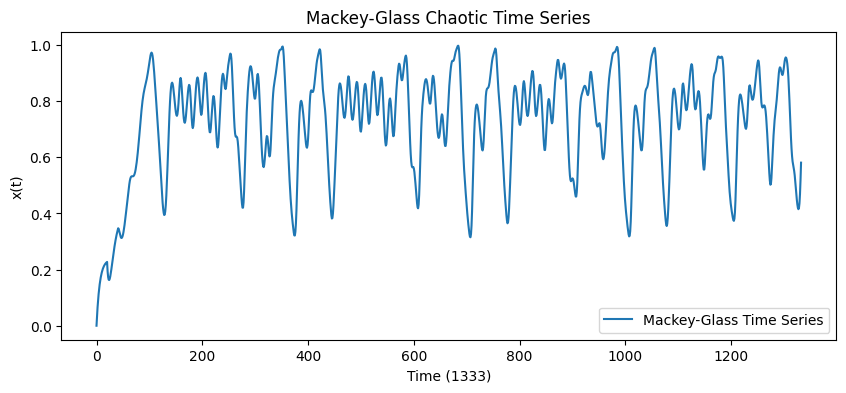

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Simulates the Mackey-Glass time series using the 4th-order Runge-Kutta method.
#   As the result will be generated from quantum measurement, we need to scale it to [0..1]
def mackey_glass(beta=0.2, gamma=0.1, n=10, tau=17, dt=0.1, T=1000):
    
    N = int(T / dt)                # Total number of time steps
    delay_steps = int(tau / dt)    # Delay in terms of steps
    x = np.zeros(N + delay_steps)  # Initialize time series with zeros
    x[0:delay_steps] = 1.2         # Initial condition

    for t in range(delay_steps, N + delay_steps - 1):
        x_tau = x[t - delay_steps]  # Delayed term
        dxdt = beta * x_tau / (1 + x_tau**n) - gamma * x[t]  # Mackey-Glass equation
        x[t + 1] = x[t] + dxdt * dt  # Euler integration

    x_min, x_max = np.min(x), np.max(x)
    x = (x - x_min) / (x_max - x_min)

    return x[delay_steps:]  # Return only the valid part of the time series

# Generate and plot the Mackey-Glass time series
# time_series = mackey_glass(dt=1, T=2000)
time_series_mg = mackey_glass(beta=0.17, dt=1.5, T=2000, tau=30)
chart_name_mg = 'Mackey-Glass'

plt.figure(figsize=(10, 4))
plt.plot(time_series_mg, label=f'{chart_name_mg} Time Series')
plt.xlabel(f'Time ({len(time_series_mg)})')
plt.ylabel('x(t)')
plt.title(f'{chart_name_mg} Chaotic Time Series')
plt.legend()
plt.show()

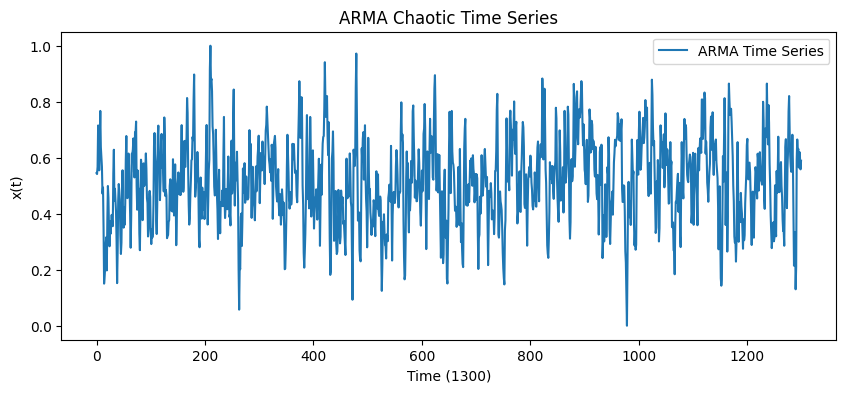

In [4]:
def generate_arma_data(n_points=1000, ar_coeffs=[1, -0.7], ma_coeffs=[1, 0.5, -0.3], seed=42):
    """Generate an ARMA time series."""
    from scipy.signal import lfilter

    np.random.seed(seed)
    noise = np.random.normal(0, 1, n_points)
    data = lfilter(ma_coeffs, ar_coeffs, noise)

    d_min, d_max = np.min(data), np.max(data)
    d = (data - d_min) / (d_max - d_min)
    
    return d

# Generate and plot the ARMA time series
time_series_arm = generate_arma_data(n_points=1300)
chart_name_arm = 'ARMA'

plt.figure(figsize=(10, 4))
plt.plot(time_series_arm, label=f'{chart_name_arm} Time Series')
plt.xlabel(f'Time ({len(time_series_arm)})')
plt.ylabel('x(t)')
plt.title(f'{chart_name_arm} Chaotic Time Series')
plt.legend()
plt.show()

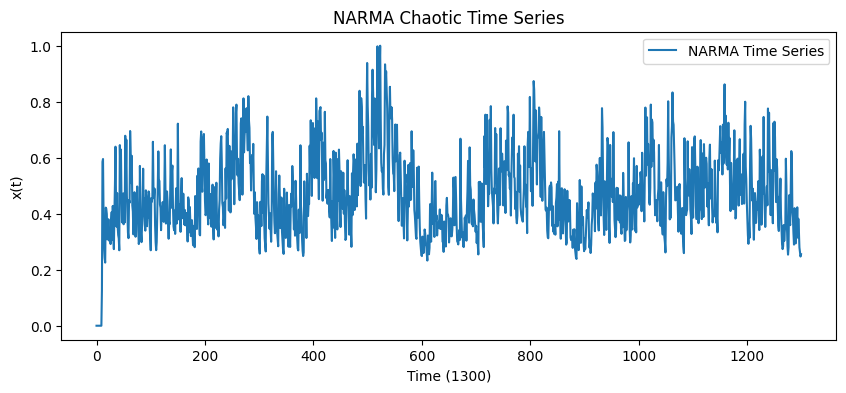

In [5]:
def generate_narma_data(n_points=2000, order=10, alpha=0.3, beta=0.05, gamma=1.5, delta=0.1, seed=42):
    """Generate a NARMA time series."""
    np.random.seed(seed)
    s = np.random.uniform(0, 0.5, n_points)
    y = np.zeros(n_points)

    for k in range(order, n_points):
        sum_term = np.sum(y[k-order:k])
        y[k] = (alpha * y[k-1] +
                beta * y[k-1] * sum_term +
                gamma * s[k-order] * s[k] +
                delta)

    d_min, d_max = np.min(y), np.max(y)
    d = (y - d_min) / (d_max - d_min)
    
    return d

# Generate and plot the NARMA time series
time_series_narm = generate_narma_data(n_points=1300)
chart_name_narm = 'NARMA'

plt.figure(figsize=(10, 4))
plt.plot(time_series_narm, label=f'{chart_name_narm} Time Series')
plt.xlabel(f'Time ({len(time_series_narm)})')
plt.ylabel('x(t)')
plt.title(f'{chart_name_narm} Chaotic Time Series')
plt.legend()
plt.show()

In [6]:
time_series = time_series_narm
chart_name = chart_name_narm

### Prepare trainig and testing data partitions

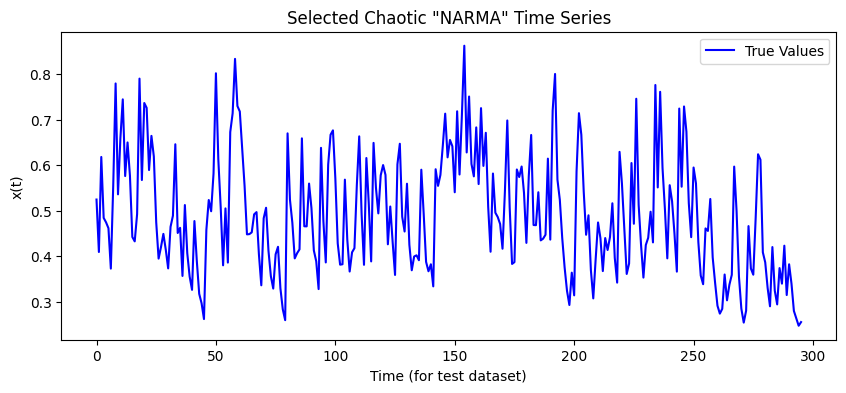

In [7]:
### Prepare the data, scale to [0..1]
def create_io_pairs(data, window_size):
    """
    Create input-output pairs for training/testing.
    """
    inputs = []
    outputs = []
    for i in range(len(data) - window_size):
        inputs.append(data[i:i + window_size])
        outputs.append(data[i + window_size])
    return np.array(inputs), np.array(outputs)

### Data settings
window_size = 4 # 10  # Use the last ws time steps to predict the next step
train_size = 1000  # Use the first trs points for training
test_size = 500   # Use the next tst points for testing

### Create data
train_inputs, train_outputs = create_io_pairs(time_series[:train_size], window_size)
test_inputs, test_outputs = create_io_pairs(time_series[train_size:train_size + test_size], window_size)

### Plot the test set
plt.figure(figsize=(10, 4))
plt.plot(test_outputs, label="True Values", color="blue")
plt.xlabel('Time (for test dataset)')
plt.ylabel('x(t)')
plt.title(f'Selected Chaotic "{chart_name}" Time Series')
plt.legend()
plt.show()

## Model development

In [8]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import torch

### Model settings

In [9]:
### Simulator settings
sim = 'lightning.qubit' # 'default.qubit' # 
interface = 'autograd' # 'torch' # 
diff_method = 'adjoint' # 'parameter-shift' # 
level='gradient'
shots = None

In [10]:
### Quantum reservoir hyper-parameters
n_qubits = window_size  # Number of qubits in the reservoir
n_layers = 4  # Number of layers in the quantum circuit
seed = 2025   # Random seed used throughout
weight_scaler = 0.2
bias_scaler = 0.2
phase_scaler = 1.0
use_IQP = False

### Quantum device to use
dev = qml.device(sim, wires=n_qubits, seed=seed)

### Utilities

In [11]:
### Draw this circuit beautifully as in Qiskit
#   Lots of styles apply, e.g. 'black_white', 'black_white_dark', 'sketch', 
#     'pennylane', 'pennylane_sketch', 'sketch_dark', 'solarized_light', 'solarized_dark', 
#     'default', we can even use 'rcParams' to redefine all attributes
#   level = None, 'user', 'top', 'device', 'gradient', 0, 1, ...
def draw_circuit(circuit, fontsize=20, style='pennylane', 
                 scale=None, title=None, decimals=2, level='user'):
    def _draw_circuit(*args, **kwargs):
        nonlocal circuit, fontsize, style, scale, title, level
        qml.drawer.use_style(style)
        fig, ax = qml.draw_mpl(circuit, decimals=decimals, level=level)(*args, **kwargs)
        if scale is not None:
            dpi = fig.get_dpi()
            fig.set_dpi(dpi*scale)
        if title is not None:
            fig.suptitle(title, fontsize=fontsize)
        plt.show()
    return _draw_circuit

### Create a quantum feature map

In [12]:
def zz_feature_map(features, scaler=2.0, IQP=False):
    """
    Implements the original ZZ feature map, which can also be used
    as part of a differentiable circuit (in contrast to IQP).

    Use
        zz_feature_map(input, scaler=2.0, IQP=False) same as
            Qiskit ZZ feature map
        zz_feature_map(input, scaler=1.0, IQP=True) same as
            PennyLane IQP
        Otherwise custom scaling appropriate for IQP/ZZFM
    Args
        features: input values
        IQP = True: if true, enforces simple product of 2nd order terms
        scaler = 1.0: scales all Z and ZZ terms, 2.0 for Havlicek form
    Returns
        ZZ feature map
    """
    n_wires = len(features)
    
    # 1. Apply Hadamard gates
    for i in range(n_wires):
        qml.Hadamard(wires=i)
        
    # 2. First-order Z rotations
    for i in range(n_wires):
        qml.RZ(scaler * features[i], wires=i)
        
    # 3. Second-order ZZ interactions (Entanglement layer)
    for i in range(n_wires):
        for j in range(i + 1, n_wires):
            # The ZZ interaction is implemented by e^(-i * phi/2 * Z ⊗ Z)
            # which PennyLane represents as the MultiRZ gate
            if IQP:
                angle = scaler * features[i] * features[j]
            else:
                angle = scaler * (np.pi - features[i]) * (np.pi - features[j])
            qml.MultiRZ(angle, wires=[i, j])

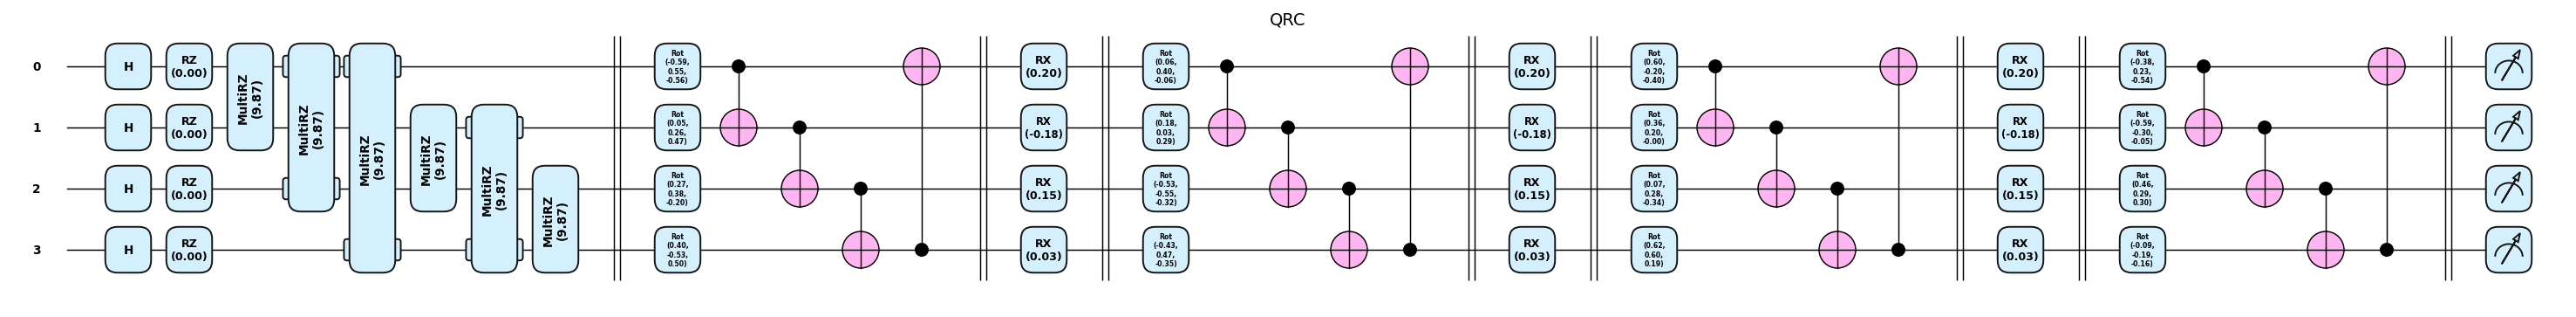

In [13]:
@qml.qnode(dev, interface=interface, diff_method=diff_method)
def quantum_feature_map(inputs, weights, biases, n_layers=1, n_qubits=4, 
                        phase_scaler=0.5, IQP=True):
    """
    Quantum circuit that acts as a feature map.
    Its only job is to encode the current classical state into
    multidimensional quantum features.
    
    Args:
        inputs: The current classical state of the ESN.
        weights: Reservoir weights (fixed).
        biases: Input biases (fixed).
    Returns:
        observables: Quantum features
    """
    # Encode the classical input into the quantum state vector
    # - using biases in ZZ fm is not recommended
    zz_feature_map(inputs, scaler=phase_scaler, IQP=IQP)
    qml.Barrier()

    # Reservoir dynamics (fixed weights)
    for layer in range(n_layers):
        # Rotational layer
        for i in range(n_qubits):
            qml.Rot(*weights[layer, i], wires=i)
        # Entanglement layer
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits-1, 0])
        qml.Barrier()
        # Reuploading layer
        if layer+1 < n_layers:
            for i in range(n_qubits):
                total_angle = inputs[i] + biases[i]
                qml.RX(total_angle, wires=i)
            qml.Barrier()

    # Return quantum features (observables)
    return [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] + \
           [qml.expval(qml.PauliY(i)) for i in range(n_qubits)] + \
           [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

### Show the model
t_n_qubits = window_size
t_n_layers = n_layers
t_inputs = train_inputs
t_weights = np.random.uniform(-np.pi, np.pi, (t_n_layers, t_n_qubits, 3))*weight_scaler
t_biases = np.random.uniform(-1, 1, t_n_qubits)*bias_scaler

draw_circuit(quantum_feature_map, scale=0.7, title="QRC", level='user') \
    (t_inputs[0], t_weights, t_biases, 
     n_layers=t_n_layers, n_qubits=t_n_qubits, phase_scaler=phase_scaler, IQP=use_IQP)

### Create and train the reservoir (includes the readout layer)

In [14]:
### The ESN-based training function, which has the following steps:
#   1. Compute the sequence of classical reservoir states
#   2. Map these classical states to quantum features
#   3. Train the readout layer using ridge regression

def train_esn_reservoir(train_inputs, train_outputs, n_layers=1, n_qubits=4, 
                        leakage_rate=0.1, lambda_reg=1e-6, seed=0):
    """
    Trains a quantum reservoir using a classical Echo State Network for memory.
    
    Args:
        train_inputs: Training input data (shape [n_samples, n_features]).
        train_outputs: Target values (shape [n_samples]).
        n_layers: Number of reservoir layers.
        n_qubits: Number of qubits.
        leakage_rate (α): Controls the ESN's memory retention.
        lambda_reg: Ridge regression parameter.      
    Returns:
        W_out: Readout weights.
        weights: Reservoir weights.
        biases: Input biases.
    """
    # Initialize parameters (these are fixed for the reservoir)
    if seed != 0: np.random.seed(seed)
    weights = np.random.uniform(-np.pi, np.pi, (n_layers, n_qubits, 3))*weight_scaler
    biases = np.random.uniform(-1, 1, n_qubits)*bias_scaler
    n_observables = 3 * n_qubits
    n_samples = len(train_inputs)

    # 1. Compute the classical ESN states
    classical_states = np.zeros((n_samples, n_qubits))
    current_classical_state = np.zeros(n_qubits)

    # Update classical state using the ESN rule
    for t in range(n_samples):
        # The ESN state update equation
        # Note: We broadcast the scalar input across the state vector
        current_classical_state = \
            (1 - leakage_rate) * current_classical_state + \
            leakage_rate * train_inputs[t]
        classical_states[t] = current_classical_state

    # 2. Map classical states to quantum features
    quantum_features = np.zeros((n_samples, n_observables))
    for t in range(n_samples):
        quantum_features[t] = quantum_feature_map(
            inputs=classical_states[t], weights=weights, biases=biases,
            n_layers=n_layers, n_qubits=n_qubits, 
            phase_scaler=phase_scaler, IQP=use_IQP
        )
    
    # 3. Train the readout layer using Ridge regression
    R = quantum_features
    Y = train_outputs.reshape(-1, 1)
    I = np.eye(n_observables)
    W_out = np.linalg.solve(R.T @ R + lambda_reg * I, R.T @ Y).flatten()
    
    return W_out, weights, biases

### Predict test targets

In [15]:
### The ESN-based prediction function.
#   It simulates the ESN state evolution and uses the quantum feature map
#   at each time step to make its prediction.

def predict_esn(test_inputs, weights, biases, W_out, n_layers=1, n_qubits=4, leakage_rate=0.1):
    """
    Makes predictions using the trained ESN-Quantum Reservoir model.
    
    Args:
        test_inputs: Test input data (shape [n_samples, n_features]).
        weights: Reservoir weights.
        biases: Input biases.
        W_out: Readout weights.
        leakage_rate (gamma): Controls the ESN's memory retention.
    Returns:
        predictions: Target test values (shape [n_samples]).
    """
    # Initialize predictoins and the classical state
    predictions = [] 
    current_classical_state = np.zeros(n_qubits)

    for input_val in test_inputs:
        
        # Update classical state using the ESN rule
        current_classical_state = \
            (1 - leakage_rate) * current_classical_state + \
            leakage_rate * input_val
        
        # Get quantum features for the current classical state
        q_features = quantum_feature_map(
            inputs=current_classical_state, weights=weights, biases=biases,
            n_layers=n_layers, n_qubits=n_qubits, 
            phase_scaler=phase_scaler, IQP=use_IQP
        )
        
        # Predict using the trained readout weights
        y_pred = np.dot(W_out, q_features)
        predictions.append(y_pred)
        
    return np.array(predictions)

### Test the QRC to demonstrate the memory effect

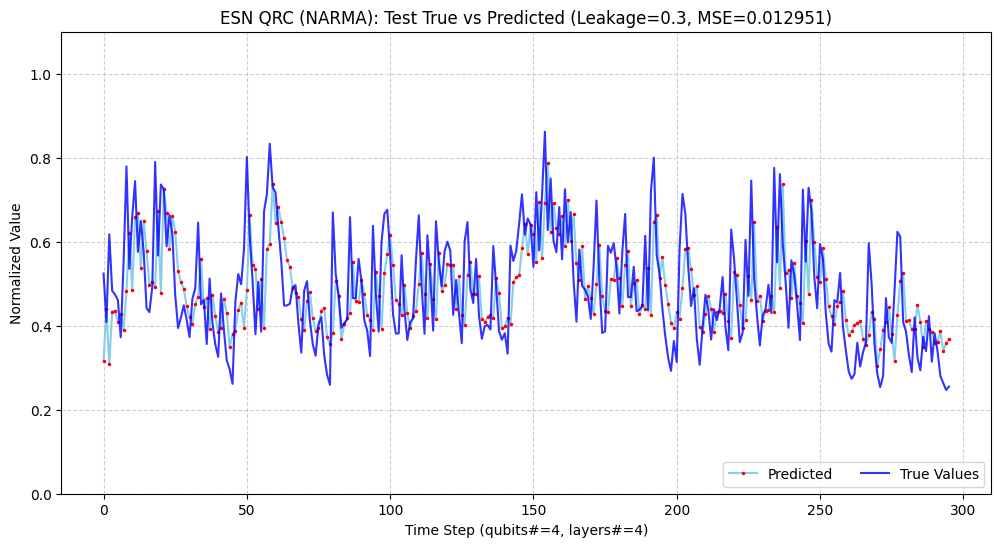

In [16]:
### Conduct a single test

# For reproducibility
np.random.seed(seed)

# Select leakage rate which relies on memory
test_leakage = 0.3

# Create the reservoir and train it
W_out, weights, biases = train_esn_reservoir(
    train_inputs, 
    train_outputs, 
    n_layers=n_layers, 
    n_qubits=n_qubits,
    leakage_rate=test_leakage
)

# Predict test targets
test_preds = predict_esn(test_inputs, weights, biases, W_out, 
                         n_layers=n_layers, n_qubits=n_qubits, leakage_rate=test_leakage)
mse = np.mean((test_preds - test_outputs)**2)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test_preds, label="Predicted", color="skyblue", linestyle="-", marker='.', 
         markerfacecolor="red", markeredgecolor="red", markersize=3)
plt.plot(test_outputs, label="True Values", color="blue", alpha=0.8)
plt.xlabel(f'Time Step (qubits#={n_qubits}, layers#={n_layers})')
plt.ylabel("Normalized Value")
plt.ylim(0, 1.1)
plt.title(f'ESN QRC ({chart_name}): Test True vs Predicted (Leakage={test_leakage}, MSE={mse:0.6f})')
plt.legend(loc='lower right', ncol=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Experiment with leakage

In [17]:
import time

# Train with different leakage rates to find the optimum
leakage_rates = [0.01, 0.03, 0.05, 0.07, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
qrc_params = []
train_mse_scores = []
test_mse_scores = []

print('\nStart leakage processing\n')

### Set the clock
start_time = time.time() 

# Try different leakage rates
for rate in leakage_rates:
    # For reproducibility
    # and consistency with above test
    np.random.seed(seed)
    
    W_out, weights, biases = train_esn_reservoir(
        train_inputs, 
        train_outputs, 
        n_layers=n_layers, 
        n_qubits=n_qubits,
        leakage_rate=rate
    )
    
    train_preds = predict_esn(train_inputs, weights, biases, W_out, 
                             n_layers=n_layers, n_qubits=n_qubits, leakage_rate=rate)
    train_mse = np.mean((train_preds - train_outputs)**2)
    test_preds = predict_esn(test_inputs, weights, biases, W_out, 
                             n_layers=n_layers, n_qubits=n_qubits, leakage_rate=rate)
    test_mse = np.mean((test_preds - test_outputs)**2)    
    current_params = (W_out, weights, biases, rate, test_mse, train_mse)
    
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)
    qrc_params.append(current_params)
    
    # Report leakage rate processing
    elapsed_time = time.time()-start_time
    
    print(f'Leakage rate [{len(train_mse_scores):02d}]: {rate:0.3f} ({int(elapsed_time):04d} sec) '+\
          f'train mse: {train_mse:0.6f}, '+\
          f'test  mse: {test_mse:0.6f}')

### Report best scores
best_train_mse = np.min(train_mse_scores)
best_train_iter = np.argmin(train_mse_scores)
best_test_mse = np.min(test_mse_scores)
best_test_iter = np.argmin(test_mse_scores)
best_train_leakage = leakage_rates[best_train_iter]
best_test_leakage = leakage_rates[best_test_iter]
best_params = qrc_params[best_test_iter]

### Print the training summary
print(f'\nLeakage processing completed: iters={len(train_mse_scores):02d}\n'+\
      f'\tmin train rate={best_train_leakage:0.3f} - {best_train_mse:0.6f} @ {best_train_iter:02d}\n'+\
      f'\tmin test  rate={best_test_leakage:0.3f} - {best_test_mse:0.6f} @ {best_test_iter:02d}\n'+\
      f'\ttime={int(elapsed_time):03d} secs\n')


Start leakage processing

Leakage rate [01]: 0.010 (0012 sec) train mse: 0.013699, test  mse: 0.036985
Leakage rate [02]: 0.030 (0022 sec) train mse: 0.013336, test  mse: 0.021121
Leakage rate [03]: 0.050 (0032 sec) train mse: 0.012719, test  mse: 0.018451
Leakage rate [04]: 0.070 (0042 sec) train mse: 0.012114, test  mse: 0.017578
Leakage rate [05]: 0.100 (0052 sec) train mse: 0.011464, test  mse: 0.016306
Leakage rate [06]: 0.200 (0062 sec) train mse: 0.010889, test  mse: 0.013865
Leakage rate [07]: 0.300 (0072 sec) train mse: 0.011158, test  mse: 0.012951
Leakage rate [08]: 0.400 (0083 sec) train mse: 0.011969, test  mse: 0.013380
Leakage rate [09]: 0.500 (0093 sec) train mse: 0.013280, test  mse: 0.014204
Leakage rate [10]: 0.600 (0103 sec) train mse: 0.014838, test  mse: 0.015253
Leakage rate [11]: 0.700 (0113 sec) train mse: 0.016524, test  mse: 0.016475
Leakage rate [12]: 0.800 (0123 sec) train mse: 0.018312, test  mse: 0.017714
Leakage rate [13]: 0.900 (0133 sec) train mse: 0.

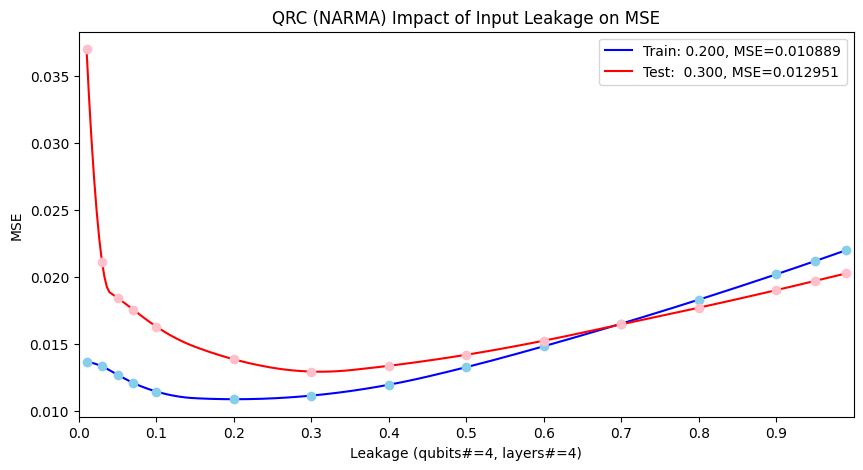

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Example data
X = np.array(leakage_rates)
y_test = np.array(test_mse_scores)
y_train = np.array(train_mse_scores)

# Generate smooth curve using spline interpolation
X_smooth = np.linspace(X.min(), X.max(), 300)  # 300 points for smoothness
train_spline = make_interp_spline(X, y_train, k=2)  # Cubic spline (k=3)
y_train_smooth = train_spline(X_smooth)
test_spline = make_interp_spline(X, y_test, k=2)  # Cubic spline (k=3)
y_test_smooth = test_spline(X_smooth)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(X_smooth, y_train_smooth, '-', color="blue", label=f'Train: {best_train_leakage:0.3f}, MSE={best_train_mse:0.6f}')  # Smoothed line
plt.plot(X, y_train, 'o', color="skyblue")
plt.plot(X_smooth, y_test_smooth, '-', color="red", label=f'Test:  {best_test_leakage:0.3f}, MSE={best_test_mse:0.6f}')  # Smoothed line
plt.plot(X, y_test, 'o', color="pink")
plt.title(f'QRC ({chart_name}) Impact of Input Leakage on MSE')
plt.xlabel(f'Leakage (qubits#={n_qubits}, layers#={n_layers})')
plt.ylabel(f'MSE')
plt.xlim(0, 1)
start, end = plt.xlim()
plt.xticks(np.arange(start, end, 0.1))
plt.legend(ncol=1)
plt.show()

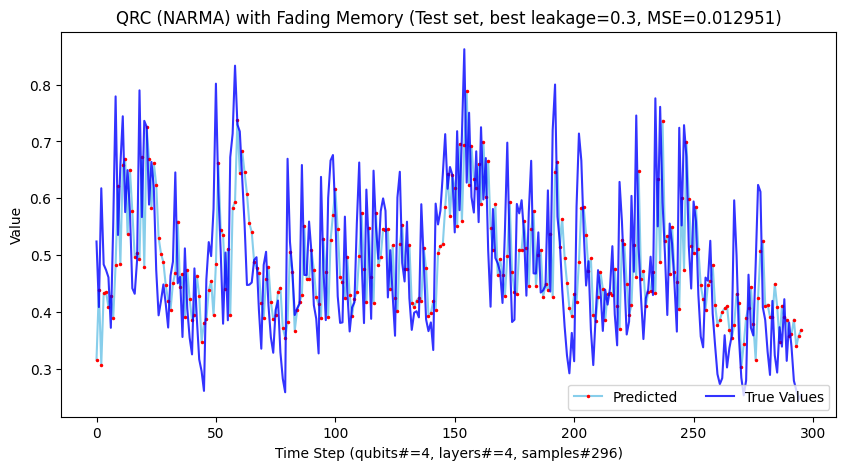

In [19]:
# Use best parameters for final prediction
W_out, weights, biases, best_rate, best_mse, _ = qrc_params[best_test_iter]

# Predict test targets
test_preds = predict_esn(test_inputs, weights, biases, W_out, 
                         n_layers=n_layers, n_qubits=n_qubits, leakage_rate=best_rate)

# Plot the result
plt.figure(figsize=(10, 5))
plt.plot(test_preds, label="Predicted", color="skyblue", linestyle="-", marker='.', 
         markerfacecolor="red", markeredgecolor="red", markersize=3)
plt.plot(test_outputs, label="True Values", color="blue", alpha=0.8)
plt.xlabel(f'Time Step (qubits#={n_qubits}, layers#={n_layers}, samples#{len(test_inputs)})')
plt.ylabel("Value")
#plt.ylim(0.2, 1.1)
plt.title(f'QRC ({chart_name}) with Fading Memory (Test set, best leakage={best_rate}, MSE={best_mse:0.6f})')
plt.legend(loc='lower right', ncol=2)
plt.show()

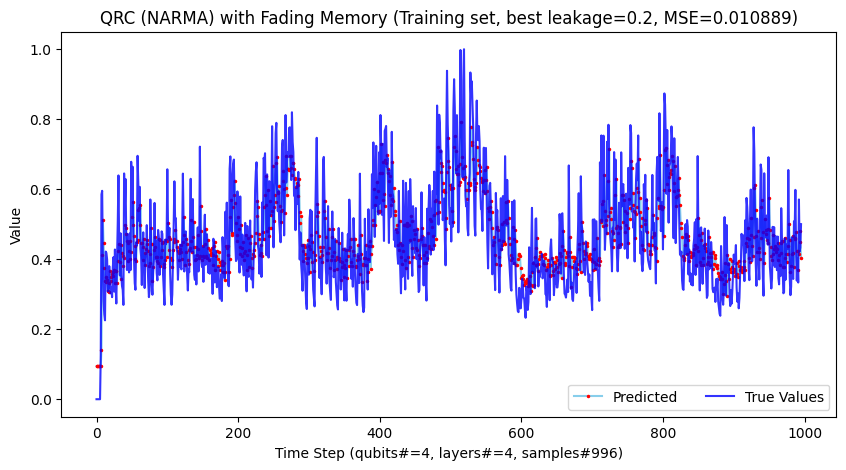

In [20]:
# Use best parameters for final prediction
W_out, weights, biases, best_rate, _, best_mse = qrc_params[best_train_iter]

# Predict training targets
train_preds = predict_esn(train_inputs, weights, biases, W_out, 
                         n_layers=n_layers, n_qubits=n_qubits, leakage_rate=best_rate)

# Plot the result
plt.figure(figsize=(10, 5))
plt.plot(train_preds, label="Predicted", color="skyblue", linestyle="-", marker='.', 
         markerfacecolor="red", markeredgecolor="red", markersize=3)
plt.plot(train_outputs, label="True Values", color="blue", alpha=0.8)
plt.xlabel(f'Time Step (qubits#={n_qubits}, layers#={n_layers}, samples#{len(train_inputs)})')
plt.ylabel("Value")
#plt.ylim(0.2, 1.1)
plt.title(f'QRC ({chart_name}) with Fading Memory (Training set, best leakage={best_rate}, MSE={best_mse:0.6f})')
plt.legend(loc='lower right', ncol=2)
plt.show()

## Write your observations here
The workshop version of the QRC has been completely rewritten as follows:
- Observation 1: 
  - Mackey-Glass time series generator used to produce values of arbitrary range. Considering that the
    time series is split into windows with both X and y vectors using these values, and the estimated y values
    are produced in the process of the expectation value measurement, the sub-range of [-1..1] is more appropriate.
    The function was subsequently changed to scale the time series values to a range of [0..1].
- Observation 2:
  - The second issue was an invalid assumption that the quantum reservoir is in the exponential Hamiltonian space.
    However, the circuit measures the expectation values of Pauli observables (X, Y, and Z) for each qubit,
    which results in the space $3 \times \textit{the number of qubits}$. Considering that the time series window
    was of size 10, and the number of qubits used was 4, this shifted the input dimensionality from 10 to 12 only,
    resulting in the QRC poor performance. For the purpose of illustration, in this notebook, we decreased the
    window size to 5 and retained 4 qubits to generate the quantum reservoir, which increased the input dimensionality
    from 5 to 12, with much better results. Increasing the number of qubits further, e.g. to 6, produces a much better
    fit for the Mackey-Glass time series.
- Observation 3:
  - A few other corrections have also been made, e.g. ensuring that the same leakage rate is passed to the
    reservoir training and prediction, and that the random seed is used consistently in a single test as well as
    in the test of different leakage rates. Small plotting adjustments have also been made
    (also to ensure comparability with the quantum QRC).
- Observation 4:
  - As the original QRC did not show an impact of memory, the model has been rewritten to incorporate Echo State Networks (ESNs) to
    classically implement the reservoir's memory dynamics, and quantum processing to act as a stateless feature map, which has the
    sole responsibility for taking the current classical state and mapping it to a vector of quantum observables.
- Observation 5:
  - It seems that the QRC is not relying on its long-term memory
    (reservoir) and only the short-term memory (window) has any
    imapact on the computation (leakage-mse plot seems linear).
  - To fix this problem, we have replaced the Rx data encoding,
    which ensured that only linear transformations occurred.
    Instead, we have deployed a two-prong strategy, i.e. use
    ZZ feature map to encode data in phase, and introduce Rx
    reuploading.
- Observation 6:
- Observation 7:

# Software in use (Linux)

In [21]:
import os
os.system('pip list | grep -e pennylane -e torch');

pennylane                 0.45.0
pennylane_lightning       0.45.0
pennylane_lightning_gpu   0.45.0
torch                     2.11.0+cpu
torchaudio                2.11.0
torcheval                 0.0.7
torchmetrics              1.9.0
torchsummary              1.5.1
torchvision               0.26.0+cpu
